In [30]:
# 데이터셋 로드
import pandas as pd
raw_df = pd.read_csv("../data/raw/amazon.csv")
raw_df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [31]:
# 데이터셋 구조 이해 (raw)
raw_df.info()

# 모두 문자형. 형변환 필요.
# 결측치 rating_count 컬럼에 2개 존재

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB


In [32]:
# 필요없는 피처 삭제
print(raw_df.columns)  # 삭제 전
df = raw_df.drop(['product_id', 'product_name', 'about_product', 'user_id', 'user_name', 'review_id', 'img_link', 'product_link'], axis=1)
print(df.columns)  # 삭제 후

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='str')
Index(['category', 'discounted_price', 'actual_price', 'discount_percentage',
       'rating', 'rating_count', 'review_title', 'review_content'],
      dtype='str')


In [33]:
df.head()

,category,discounted_price,actual_price,discount_percentage,rating,rating_count,review_title,review_content
0,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...
1,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...
2,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a..."
3,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou..."
4,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th..."


In [34]:
# 데이터셋 구조 이해
df.info()

# 모두 문자형. 형변환 필요.
# 결측치 rating_count 컬럼에 2개 존재

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   category             1465 non-null   str  
 1   discounted_price     1465 non-null   str  
 2   actual_price         1465 non-null   str  
 3   discount_percentage  1465 non-null   str  
 4   rating               1465 non-null   str  
 5   rating_count         1463 non-null   str  
 6   review_title         1465 non-null   str  
 7   review_content       1465 non-null   str  
dtypes: str(8)
memory usage: 91.7 KB


In [35]:
df.describe()

,category,discounted_price,actual_price,discount_percentage,rating,rating_count,review_title,review_content
count,1465,1465,1465,1465,1465,1463,1465,1465
unique,211,550,449,92,28,1143,1194,1212
top,Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa..."
freq,233,53,120,56,244,9,10,8


In [36]:
# rating_count 컬럼의 결측치 2개 처리 > 제거
df = df.dropna(subset=["rating_count"])
print(df.shape)

(1463, 8)


In [37]:
# 기호 제거 및 문자열의 형변환
df['discounted_price'] = (
    df['discounted_price']
        .str.replace('₹', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
)

df['actual_price'] = (
    df['actual_price']
        .str.replace('₹', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
)

df['discount_percentage'] = (
    df['discount_percentage']
        .str.replace('%', '', regex=False)
        .astype(float)
)

df['rating_count'] = (
    df['rating_count']
        .str.replace(',', '', regex=False)
        .astype(int)
)

In [38]:
df.head()

,category,discounted_price,actual_price,discount_percentage,rating,rating_count,review_title,review_content
0,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...
1,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...
2,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a..."
3,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou..."
4,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th..."


In [39]:
# 이상치 확인 및 처리
!pip install seaborn



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


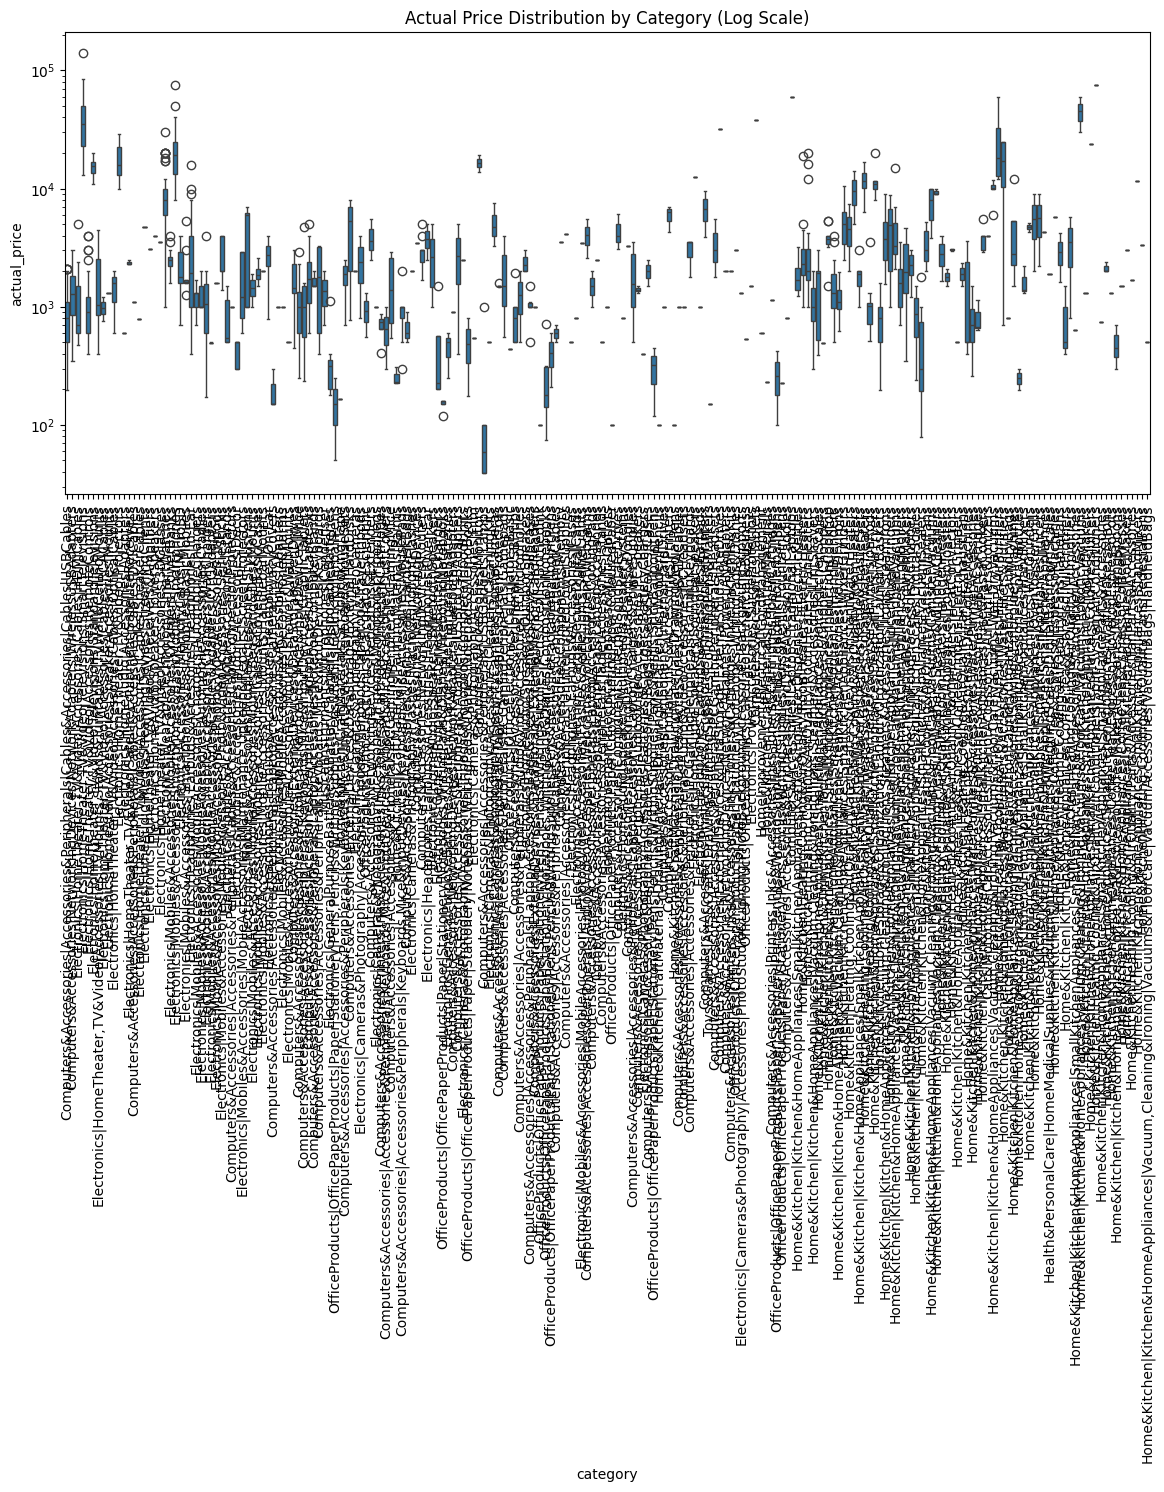

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x='category',
    y='actual_price'
)

plt.yscale('log')

plt.xticks(rotation=90)
plt.title('Actual Price Distribution by Category (Log Scale)')

plt.show()

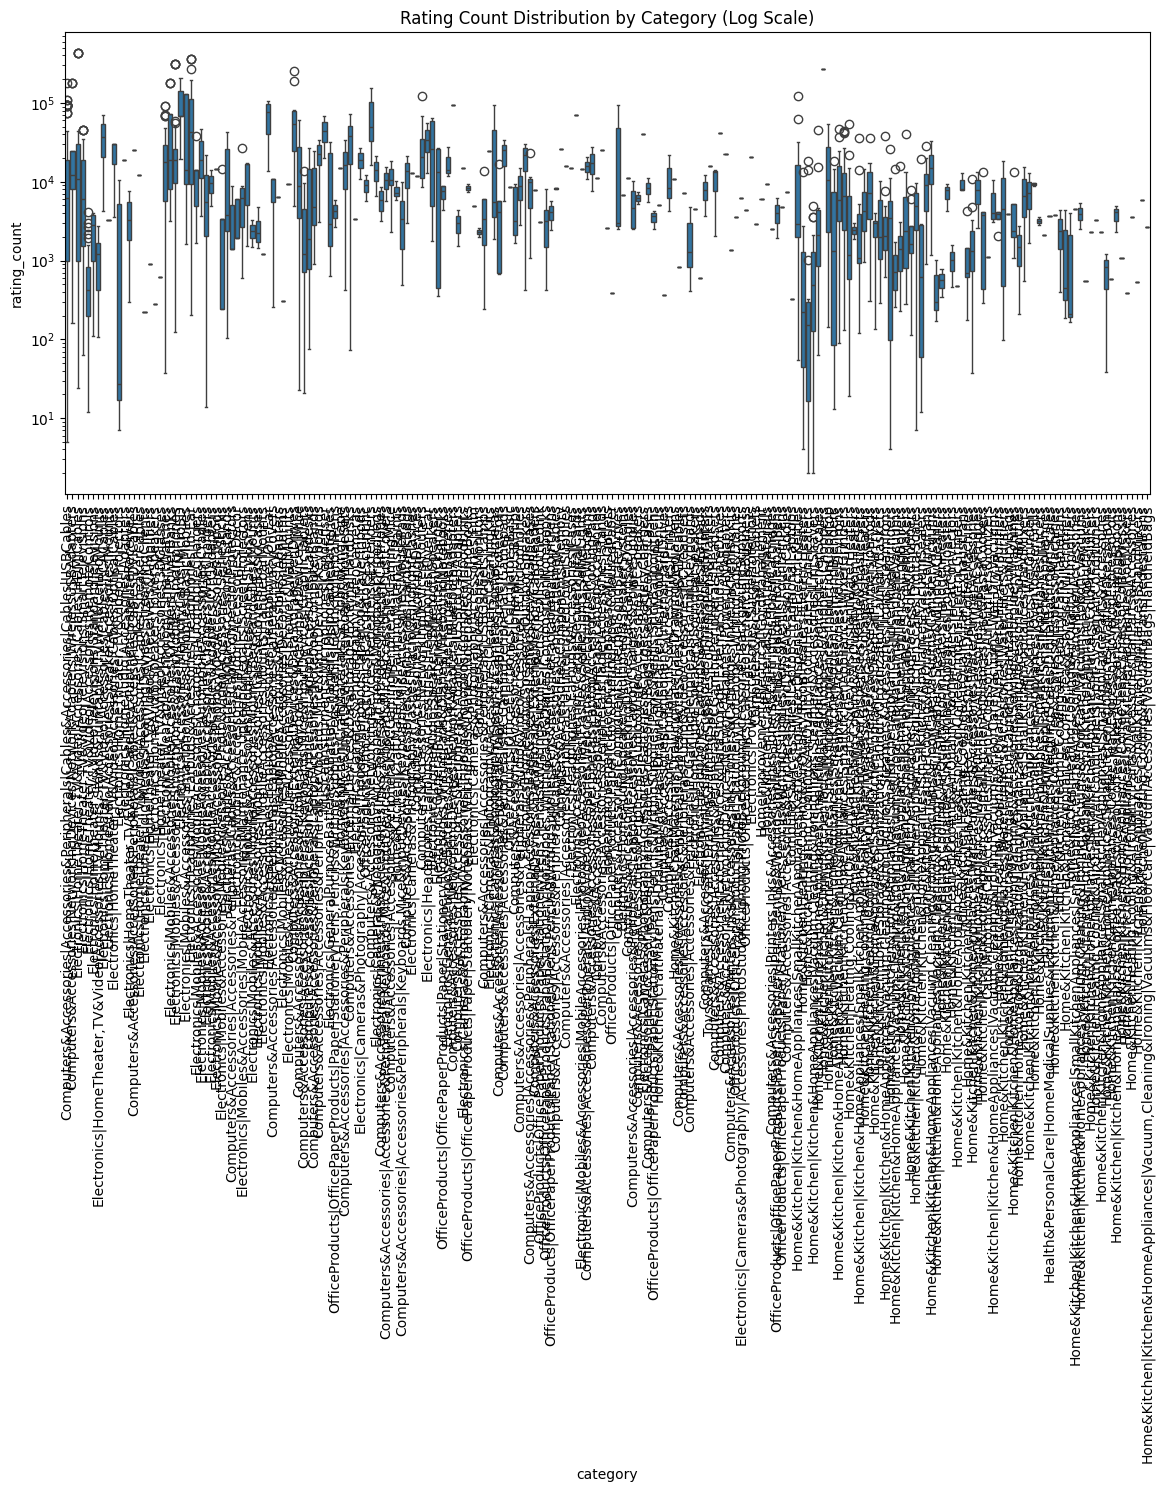

In [41]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x='category',
    y='rating_count'
)

plt.yscale('log')

plt.xticks(rotation=90)
plt.title('Rating Count Distribution by Category (Log Scale)')

plt.show()

In [42]:
# 현실 상품 데이터를 기반으로 평점 패턴을 학습하는 이 프로젝트에서 이상치 처리는 저의미하다고 판단
# (현실에서 가격 분포 치우침, 리뷰 수 극단값, 인기 상품 집중 상황이 잦기 때문)
# 또한 카테고리 수가 너무 많아 해석에 시간적 제약이 존재
# >>  따라서 이상치 대체/제거 없이 샘플 모두 그대로 유지

In [43]:
# category unique가 211개로 너무 많아서 category별 rating 분포 시각화가 어려움
# 이외에도 많은 문제가 발생할 것으로 예상하고 category 피처 삭제하기로 결정
# 자세한 건 troubleshooting.md 에 기록함

df = df.drop('category', axis=1)
df.head()

,discounted_price,actual_price,discount_percentage,rating,rating_count,review_title,review_content
0,399.0,1099.0,64.0,4.2,24269,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...
1,199.0,349.0,43.0,4.0,43994,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...
2,199.0,1899.0,90.0,3.9,7928,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a..."
3,329.0,699.0,53.0,4.2,94363,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou..."
4,154.0,399.0,61.0,4.2,16905,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th..."


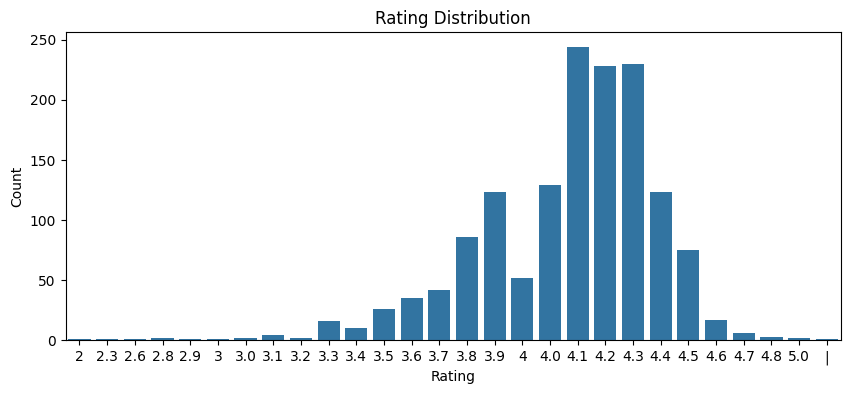

In [44]:
# rating 분포 시각화
import matplotlib.pyplot as plt
import seaborn as sns

rating_counts = df['rating'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [45]:
# rating 별 상품 개수 확인
print(df['rating'].value_counts().sort_index().to_string())

# 위에서 형변환할 때 rating은 안해줘서 str 형태로 남아있음
# 그 결과 3과 3.0 처럼 중복 발생
# 한 샘플에 rating 이 | 로 오류 나 있음 > 그 행 제거

rating
2        1
2.3      1
2.6      1
2.8      2
2.9      1
3        1
3.0      2
3.1      4
3.2      2
3.3     16
3.4     10
3.5     26
3.6     35
3.7     42
3.8     86
3.9    123
4       52
4.0    129
4.1    244
4.2    228
4.3    230
4.4    123
4.5     75
4.6     17
4.7      6
4.8      3
5.0      2
|        1


In [46]:
df['rating'] = (
    df['rating']
        .replace('|', None, regex=False)
        .astype(float)
)
df = df.dropna(subset=['rating'])
print(df.shape)

(1462, 7)


In [47]:
print(df['rating'].value_counts().sort_index().to_string())

rating
2.0      1
2.3      1
2.6      1
2.8      2
2.9      1
3.0      3
3.1      4
3.2      2
3.3     16
3.4     10
3.5     26
3.6     35
3.7     42
3.8     86
3.9    123
4.0    181
4.1    244
4.2    228
4.3    230
4.4    123
4.5     75
4.6     17
4.7      6
4.8      3
5.0      2


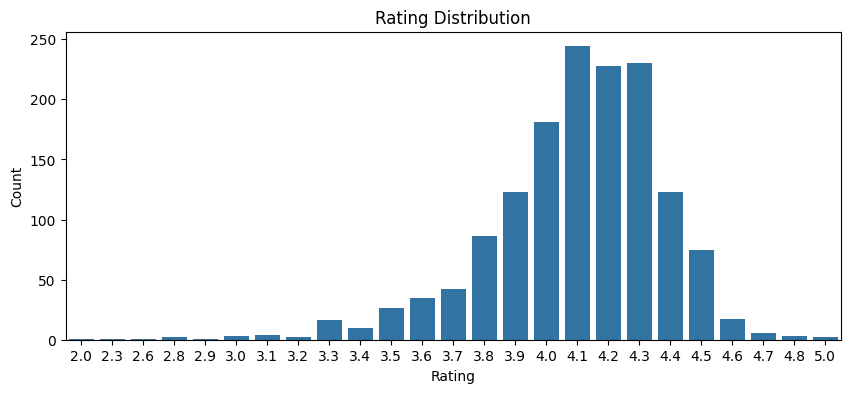

In [48]:
# rating 분포 시각화
import matplotlib.pyplot as plt
import seaborn as sns

rating_counts = df['rating'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [49]:
# count 균형을 최대한 고려하여 Low/Mid/High 결정
# Low : ~3.9
# Mid : 4.0 ~ 4.2
# High : 4.3 ~
# 타깃이 될 평점 등급 피처 rating_area 생성

def assign_rating_area(rating):
  if rating <= 3.9:
    return 'Low'
  elif rating <= 4.2:
    return 'Mid'
  else:
    return 'High'
  

df['rating_area'] = df['rating'].apply(assign_rating_area)
print(df['rating_area'].value_counts())

# Low  : 353개 (24%)
# Mid  : 653개 (45%)
# High : 456개 (31%)

rating_area
Mid     653
High    456
Low     353
Name: count, dtype: int64


In [50]:
# rating_area 매핑 (문자열의 정수화)
rating_map = {'Low' : 0, 'Mid' : 1, 'High' : 2}
df['rating_area'] = df['rating_area'].map(rating_map)
print(df['rating_area'].value_counts())

rating_area
1    653
2    456
0    353
Name: count, dtype: int64


In [52]:
df.head()

,discounted_price,actual_price,discount_percentage,rating,rating_count,review_title,review_content,rating_area
0,399.0,1099.0,64.0,4.2,24269,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,1
1,199.0,349.0,43.0,4.0,43994,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,1
2,199.0,1899.0,90.0,3.9,7928,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",0
3,329.0,699.0,53.0,4.2,94363,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",1
4,154.0,399.0,61.0,4.2,16905,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",1
